# MLA Assignment — Part 1: decision trees and tree ensembles on Fashion-MNIST

## 0. Setup

In [1]:
import os, time, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from scipy.stats import chi2
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from tensorflow.keras.datasets import fashion_mnist

RANDOM_STATE = 42
N_JOBS = -1
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, f"{name}.pdf"), bbox_inches="tight")


In [2]:

# Load the data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Preprocess the data: decision trees expect 2D input, so we need to flatten the images
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)
n_test = len(y_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    x_train_flat, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)

print(f"train {x_train_flat.shape} | test {x_test_flat.shape} | "
      f"tuning split {X_tr.shape[0]} / {X_val.shape[0]}")

train (60000, 784) | test (10000, 784) | tuning split 48000 / 12000


## 1. Data analysis

In [3]:
counts = pd.DataFrame({"train": np.bincount(y_train, minlength=10),
                       "test": np.bincount(y_test, minlength=10)}, index=CLASS_NAMES)
print(counts)

             train  test
T-shirt/top   6000  1000
Trouser       6000  1000
Pullover      6000  1000
Dress         6000  1000
Coat          6000  1000
Sandal        6000  1000
Shirt         6000  1000
Sneaker       6000  1000
Bag           6000  1000
Ankle boot    6000  1000


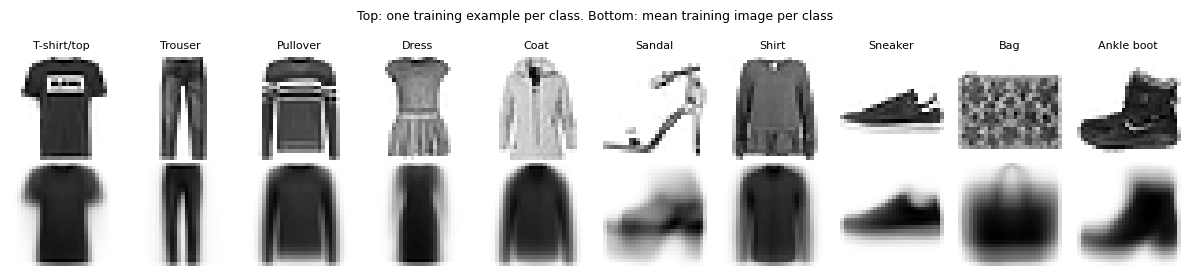

In [4]:
# One example and the mean image per class
fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for c in range(10):
    idx = np.where(y_train == c)[0]
    axes[0, c].imshow(x_train[idx[0]], cmap="gray_r")
    axes[0, c].set_title(CLASS_NAMES[c], fontsize=8)
    axes[1, c].imshow(x_train[idx].mean(axis=0), cmap="gray_r")
    axes[0, c].axis("off"); axes[1, c].axis("off")
fig.suptitle("Top: one training example per class. Bottom: mean training image per class", fontsize=9)
plt.tight_layout(); savefig("data_examples"); plt.show()

In [5]:
# We want to know how correlated the predictors are and compare horizontally adjacent pixels with random pixel pairs.
rng = np.random.default_rng(RANDOM_STATE)
sub = x_train[rng.choice(len(x_train), 10_000, replace=False)].astype(np.float32)
flat = sub.reshape(len(sub), -1)

def mean_corr(a, b):
    # mean Pearson correlation between corresponding columns of a and b
    a = (a - a.mean(0)) / a.std(0)
    b = (b - b.mean(0)) / b.std(0)
    return float((a * b).mean(0).mean())

left = sub[:, :, :-1].reshape(len(sub), -1)
right = sub[:, :, 1:].reshape(len(sub), -1)
ok = (left.std(0) > 0) & (right.std(0) > 0)          # skip constant (always-zero) pixels
adj_corr = mean_corr(left[:, ok], right[:, ok])

cols = np.where(flat.std(0) > 0)[0]
i, j = rng.choice(cols, 5000), rng.choice(cols, 5000)
keep = i != j
rand_corr = mean_corr(flat[:, i[keep]], flat[:, j[keep]])

zero_share = (flat == 0).mean(axis=0)
print(f"Mean correlation, adjacent pixels:   {adj_corr:.2f}")
print(f"Mean correlation, random pixel pairs: {rand_corr:.2f}")
print(f"Pixels that are 0 in >95% of images: {(zero_share > 0.95).sum()} of 784")

Mean correlation, adjacent pixels:   0.77
Mean correlation, random pixel pairs: 0.15
Pixels that are 0 in >95% of images: 61 of 784


## 2. Part 1a — Decision tree

In [6]:
results = {}   # used for the summary tables

def se_acc(acc, n):
    """
    Standard error of an accuracy estimated on n independent images.
    """
    return np.sqrt(acc * (1 - acc) / n)

def evaluate(name, model, fit_time=np.nan, n_trees=None, m=None, oob=np.nan):
    """
    Evaluate a FINAL model once on the test set and store the results.
    """
    y_pred = model.predict(x_test_flat)
    acc = accuracy_score(y_test, y_pred)
    results[name] = dict(
        n_trees=n_trees, m=m,
        train_acc=model.score(x_train_flat, y_train),
        test_acc=acc, test_se=se_acc(acc, n_test),
        macro_f1=f1_score(y_test, y_pred, average="macro"),
        oob_acc=oob, fit_time_s=fit_time,
        f1_per_class=f1_score(y_test, y_pred, average=None),
        y_pred=y_pred)
    r = results[name]
    print(f"{name}: train {r['train_acc']:.4f} | test {acc:.4f} (SE {r['test_se']:.4f}) | "
          f"macro-F1 {r['macro_f1']:.4f} | fit {fit_time:.1f}s")
    return y_pred

def plot_cm(y_pred, title, fname):
    """
    Plot a row-normalised confusion matrix: each row shows how one true class is predicted.
    """
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 7))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45, values_format=".2f")
    ax.set_title(title)
    plt.tight_layout(); savefig(fname); plt.show()

### 2.1 Baseline: fully grown tree

In [7]:
t0 = time.time()
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(x_train_flat, y_train)
tree_full_time = time.time() - t0
print(f"Depth {tree_full.get_depth()}, leaves {tree_full.get_n_leaves()}")
y_pred_full = evaluate("Decision tree (unpruned)", tree_full, tree_full_time)

Depth 49, leaves 4910
Decision tree (unpruned): train 1.0000 | test 0.7890 (SE 0.0041) | macro-F1 0.7899 | fit 32.1s


### 2.2 Tuning tree complexity on the validation set
Two ways of limiting complexity: a maximum depth, and cost-complexity (weakest-link) pruning with
penalty α (lecture 3a). With 12,000 validation images the SE of a validation accuracy is
about 0.4 pp, so a single hold-out set is reliable here and k-fold CV would mainly add computation.

In [8]:
def tree_row(method, param, model):
    return dict(method=method, param=param, leaves=model.get_n_leaves(),
                depth=model.get_depth(), train_acc=model.score(X_tr, y_tr),
                val_acc=model.score(X_val, y_val))

depths = [4, 6, 8, 9, 10, 11, 12, 14, 16, 20, None]
depth_rows = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    depth_rows.append(tree_row("max_depth", d, dt))
depth_df = pd.DataFrame(depth_rows)
print(depth_df.round(4).to_string(index=False))

   method  param  leaves  depth  train_acc  val_acc
max_depth    4.0      16      4     0.6545   0.6507
max_depth    6.0      64      6     0.7387   0.7352
max_depth    8.0     218      8     0.8048   0.7897
max_depth    9.0     364      9     0.8314   0.8059
max_depth   10.0     562     10     0.8509   0.8130
max_depth   11.0     806     11     0.8714   0.8152
max_depth   12.0    1101     12     0.8919   0.8193
max_depth   14.0    1802     14     0.9301   0.8143
max_depth   16.0    2563     16     0.9607   0.8091
max_depth   20.0    3410     20     0.9864   0.8034
max_depth    NaN    4124     50     1.0000   0.7973


In [9]:
# Cost-complexity pruning path. The full path holds thousands of alphas,
# so we evaluate alphas spread over the path (more pruning for higher quantiles).
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_tr, y_tr)
alpha_grid = np.unique(np.quantile(path.ccp_alphas, [0.5, 0.7, 0.8, 0.9, 0.95, 0.97, 0.99]))

ccp_rows = []
for a in alpha_grid:
    dt = DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    ccp_rows.append(tree_row("ccp_alpha", a, dt))
ccp_df = pd.DataFrame(ccp_rows)
print(ccp_df.round(6).to_string(index=False))

   method    param  leaves  depth  train_acc  val_acc
ccp_alpha 0.000053    1878     27   0.955208 0.808833
ccp_alpha 0.000083    1155     25   0.925292 0.815417
ccp_alpha 0.000107     731     19   0.898021 0.823083
ccp_alpha 0.000180     330     16   0.858188 0.822500
ccp_alpha 0.000356     159     13   0.824375 0.807333
ccp_alpha 0.000640      97     12   0.803583 0.796583
ccp_alpha 0.002355      32      8   0.743688 0.736583


In [10]:
# One-standard-error rule (ISLP §6.1.3): among all candidates whose validation accuracy is within
# one SE of the best, choose the simplest tree (fewest leaves).
cand_df = pd.concat([depth_df, ccp_df], ignore_index=True)
cand_df["val_se"] = se_acc(cand_df.val_acc, len(y_val))
best = cand_df.loc[cand_df.val_acc.idxmax()]
chosen = cand_df[cand_df.val_acc >= best.val_acc - best.val_se].sort_values("leaves").iloc[0]

print(f"Best on validation: {best.method}={best.param}, {best.leaves} leaves, "
      f"val {best.val_acc:.4f} ± {best.val_se:.4f}")
print(f"Chosen (1-SE rule): {chosen.method}={chosen.param}, {chosen.leaves} leaves, "
      f"val {chosen.val_acc:.4f}")

Best on validation: ccp_alpha=0.00010725297619047631, 731 leaves, val 0.8231 ± 0.0035
Chosen (1-SE rule): ccp_alpha=0.0001799515150428758, 330 leaves, val 0.8225


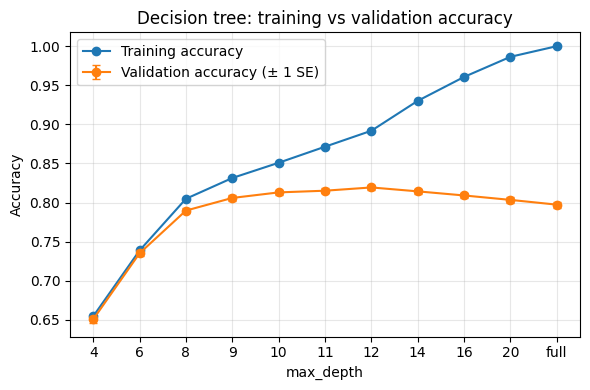

In [11]:
# Figure: training vs validation accuracy as a function of depth (bias-variance trade-off)
x = np.arange(len(depth_df))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, depth_df.train_acc, marker="o", label="Training accuracy")
ax.errorbar(x, depth_df.val_acc, yerr=se_acc(depth_df.val_acc, len(y_val)),
            marker="o", capsize=3, label="Validation accuracy (± 1 SE)")
ax.set_xticks(x)
ax.set_xticklabels(["full" if pd.isna(d) else str(int(d)) for d in depth_df.param])
ax.set_xlabel("max_depth"); ax.set_ylabel("Accuracy")
ax.set_title("Decision tree: training vs validation accuracy")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); savefig("tree_depth_curve"); plt.show()

### 2.3 Final tree: refit on the full training set, evaluate once on the test set

Final tree {'ccp_alpha': 0.0001799515150428758}: depth 15, leaves 308
Decision tree (tuned): train 0.8496 | test 0.8084 (SE 0.0039) | macro-F1 0.8085 | fit 30.8s
              precision    recall  f1-score   support

 T-shirt/top      0.768     0.801     0.784      1000
     Trouser      0.979     0.935     0.957      1000
    Pullover      0.683     0.704     0.694      1000
       Dress      0.815     0.803     0.809      1000
        Coat      0.660     0.701     0.680      1000
      Sandal      0.916     0.885     0.900      1000
       Shirt      0.562     0.524     0.542      1000
     Sneaker      0.868     0.926     0.896      1000
         Bag      0.914     0.901     0.907      1000
  Ankle boot      0.929     0.904     0.916      1000

    accuracy                          0.808     10000
   macro avg      0.809     0.808     0.809     10000
weighted avg      0.809     0.808     0.809     10000



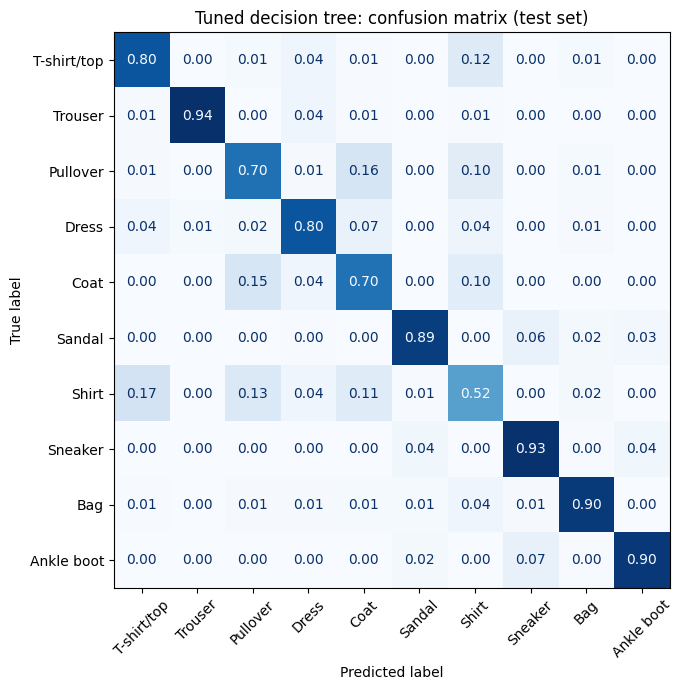

In [12]:
if chosen.method == "max_depth":
    params = {"max_depth": None if pd.isna(chosen.param) else int(chosen.param)}
else:
    params = {"ccp_alpha": float(chosen.param)}

t0 = time.time()
tree_final = DecisionTreeClassifier(**params, random_state=RANDOM_STATE).fit(x_train_flat, y_train)
tree_time = time.time() - t0
print(f"Final tree {params}: depth {tree_final.get_depth()}, leaves {tree_final.get_n_leaves()}")
y_pred_tree = evaluate("Decision tree (tuned)", tree_final, tree_time)
print(classification_report(y_test, y_pred_tree, target_names=CLASS_NAMES, digits=3))
plot_cm(y_pred_tree, "Tuned decision tree: confusion matrix (test set)", "cm_tree")

## 3. Part 1b — Tree ensembles
**Bagging vs. random forest.**

In [13]:
B_GRID = [1, 2, 5, 10, 20, 30, 50, 75, 100]

def grow_forest(max_features, label):
    """
    Grow one forest tree-by-tree and record the test accuracy at every B in B_GRID.
    The OOB accuracy is computed once, for the final B (OOB is unreliable for small B).
    """
    forest = RandomForestClassifier(max_features=max_features, warm_start=True,
                                    n_jobs=N_JOBS, random_state=RANDOM_STATE)
    curve, fit_time = [], 0.0
    for B in B_GRID:
        forest.set_params(n_estimators=B, oob_score=(B == B_GRID[-1]))
        t0 = time.time()
        forest.fit(x_train_flat, y_train)
        fit_time += time.time() - t0
        curve.append(dict(model=label, B=B, test_acc=forest.score(x_test_flat, y_test)))
    print(f"{label}: {fit_time:.1f}s, OOB accuracy {forest.oob_score_:.4f}")
    return forest, pd.DataFrame(curve), fit_time

In [14]:
# Bagging: m = p = 784
bag, bag_curve, bag_time = grow_forest(max_features=None, label="Bagging (m = 784)")

Bagging (m = 784): 415.3s, OOB accuracy 0.8737


In [15]:
# Random forest: m = sqrt(p) = 28
rf_sqrt, rf_curve, rf_time = grow_forest(max_features="sqrt", label="Random forest (m = 28)")

Random forest (m = 28): 17.2s, OOB accuracy 0.8806


model  Bagging (m = 784)  Random forest (m = 28)
B                                               
1                 0.7775                  0.7570
2                 0.7816                  0.7598
5                 0.8347                  0.8293
10                0.8545                  0.8549
20                0.8624                  0.8647
30                0.8654                  0.8715
50                0.8667                  0.8735
75                0.8690                  0.8731
100               0.8709                  0.8760


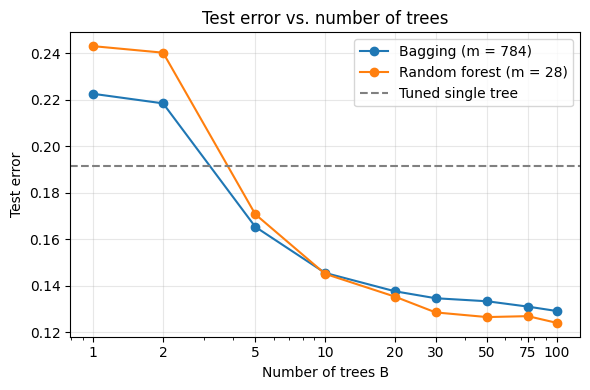

In [16]:
# Figure: test error as a function of the number of trees
curves = pd.concat([bag_curve, rf_curve])
print(curves.pivot(index="B", columns="model", values="test_acc").round(4))

fig, ax = plt.subplots(figsize=(6, 4))
for label, c in curves.groupby("model", sort=False):
    ax.plot(c.B, 1 - c.test_acc, marker="o", label=label)
ax.axhline(1 - results["Decision tree (tuned)"]["test_acc"], ls="--", c="grey", label="Tuned single tree")
ax.set_xscale("log"); ax.set_xticks(B_GRID); ax.set_xticklabels(B_GRID)
ax.set_xlabel("Number of trees B"); ax.set_ylabel("Test error")
ax.set_title("Test error vs. number of trees")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); savefig("error_vs_trees"); plt.show()

### 3.1 Choosing *m* with the OOB accuracy
Small *m* decorrelates the trees but makes every individual tree weaker; *m* = *p* is bagging.
We apply the one-SE rule again and prefer the smallest *m* (least correlated and cheapest).

In [17]:
p = x_train_flat.shape[1]
m_rows = [dict(m=p, oob_acc=bag.oob_score_, fit_time_s=bag_time),
          dict(m=28, oob_acc=rf_sqrt.oob_score_, fit_time_s=rf_time)]
for m in [10, 56, 112, 196]:
    t0 = time.time()
    forest = RandomForestClassifier(n_estimators=100, max_features=m, oob_score=True,
                                    n_jobs=N_JOBS, random_state=RANDOM_STATE).fit(x_train_flat, y_train)
    m_rows.append(dict(m=m, oob_acc=forest.oob_score_, fit_time_s=time.time() - t0))
    del forest   # free memory: 100 deep trees per forest

m_df = pd.DataFrame(m_rows).sort_values("m").reset_index(drop=True)
m_df["oob_se"] = se_acc(m_df.oob_acc, len(y_train))
best_m = m_df.loc[m_df.oob_acc.idxmax()]
chosen_m = int(m_df[m_df.oob_acc >= best_m.oob_acc - best_m.oob_se].m.min())
print(m_df.round(4).to_string(index=False))
print(f"\nBest OOB at m = {int(best_m.m)}; chosen m (1-SE rule) = {chosen_m}")

  m  oob_acc  fit_time_s  oob_se
 10   0.8749      7.5956  0.0014
 28   0.8806     17.2250  0.0013
 56   0.8818     25.3406  0.0013
112   0.8824     49.1192  0.0013
196   0.8825     82.6352  0.0013
784   0.8736    415.3272  0.0014

Best OOB at m = 196; chosen m (1-SE rule) = 56


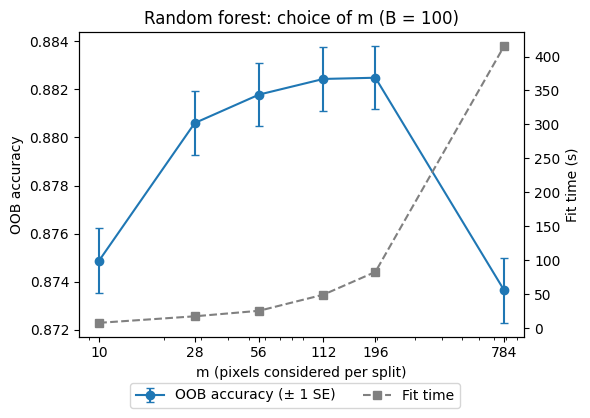

In [18]:
# Figure: OOB accuracy and fit time as a function of m
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(m_df.m, m_df.oob_acc, yerr=m_df.oob_se, marker="o", capsize=3, label="OOB accuracy (± 1 SE)")
ax.set_xscale("log"); ax.set_xticks(m_df.m); ax.set_xticklabels(m_df.m)
ax.set_xlabel("m (pixels considered per split)"); ax.set_ylabel("OOB accuracy")
ax2 = ax.twinx()
ax2.plot(m_df.m, m_df.fit_time_s, marker="s", ls="--", c="grey", label="Fit time")
ax2.set_ylabel("Fit time (s)")
ax.set_title("Random forest: choice of m (B = 100)")
fig.legend(loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(); savefig("oob_vs_m"); plt.show()

### 3.2 Final ensembles on the test set

Bagging: train 1.0000 | test 0.8709 (SE 0.0034) | macro-F1 0.8699 | fit 415.3s
Random forest (m = 28): train 1.0000 | test 0.8760 (SE 0.0033) | macro-F1 0.8745 | fit 17.2s
Random forest: train 1.0000 | test 0.8773 (SE 0.0033) | macro-F1 0.8760 | fit 24.9s
              precision    recall  f1-score   support

 T-shirt/top      0.827     0.858     0.842      1000
     Trouser      0.994     0.959     0.976      1000
    Pullover      0.765     0.806     0.785      1000
       Dress      0.876     0.908     0.892      1000
        Coat      0.769     0.814     0.791      1000
      Sandal      0.977     0.960     0.968      1000
       Shirt      0.716     0.594     0.649      1000
     Sneaker      0.928     0.954     0.941      1000
         Bag      0.958     0.972     0.965      1000
  Ankle boot      0.956     0.948     0.952      1000

    accuracy                          0.877     10000
   macro avg      0.876     0.877     0.876     10000
weighted avg      0.876     0.877     0.

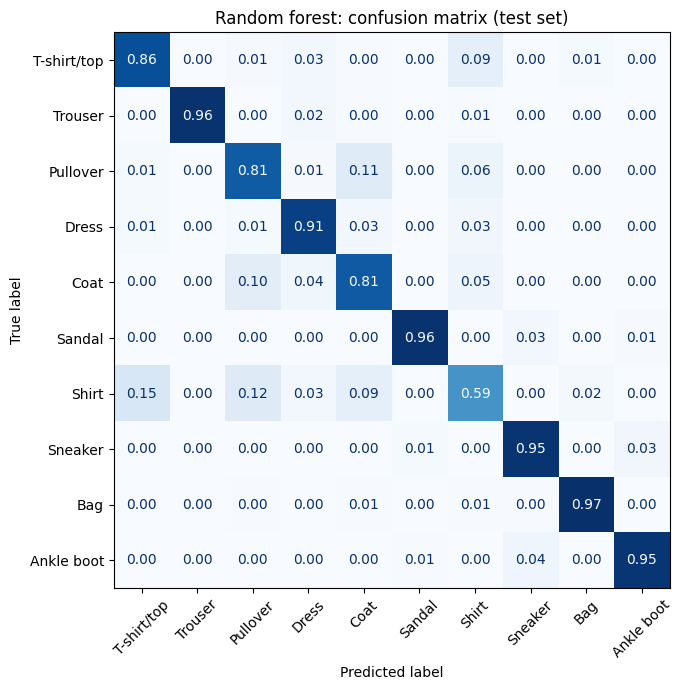

In [19]:
if chosen_m == 28:
    rf_final, rf_final_time = rf_sqrt, rf_time
else:
    t0 = time.time()
    rf_final = RandomForestClassifier(n_estimators=100, max_features=chosen_m, oob_score=True,
                                      n_jobs=N_JOBS, random_state=RANDOM_STATE).fit(x_train_flat, y_train)
    rf_final_time = time.time() - t0

y_pred_bag = evaluate("Bagging", bag, bag_time, n_trees=100, m=p, oob=bag.oob_score_)
if chosen_m != 28:   # keep the default m = sqrt(p) forest in the table as well
    evaluate("Random forest (m = 28)", rf_sqrt, rf_time, n_trees=100, m=28, oob=rf_sqrt.oob_score_)
y_pred_rf = evaluate("Random forest", rf_final, rf_final_time, n_trees=100, m=chosen_m,
                     oob=rf_final.oob_score_)
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, digits=3))
plot_cm(y_pred_rf, "Random forest: confusion matrix (test set)", "cm_rf")

### 3.3 Benchmark: gradient boosting
Boosting reduces bias by fitting shallow trees sequentially to the errors of the current model (lecture 3b); `learning_rate` is the shrinkage λ.

In [20]:
gb = HistGradientBoostingClassifier(learning_rate=0.1, max_iter=300, early_stopping=True,
                                    validation_fraction=0.1, n_iter_no_change=10,
                                    random_state=RANDOM_STATE)
t0 = time.time()
gb.fit(x_train_flat, y_train)
gb_time = time.time() - t0
print(f"Boosting rounds used (early stopping): {gb.n_iter_}")
y_pred_gb = evaluate("Gradient boosting", gb, gb_time, n_trees=gb.n_iter_)

Boosting rounds used (early stopping): 109
Gradient boosting: train 0.9879 | test 0.8962 (SE 0.0031) | macro-F1 0.8961 | fit 137.7s


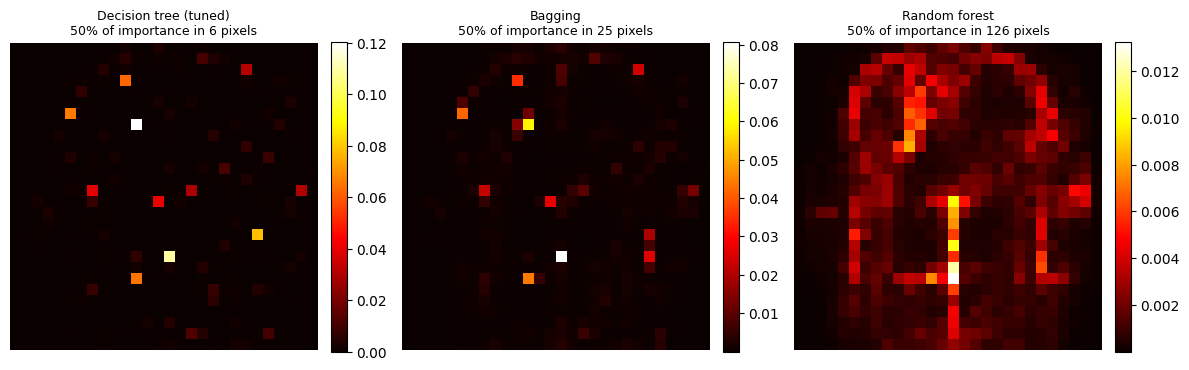

In [21]:
# Figure: impurity-based (MDI) pixel importance (lecture 3a/3b)
def n_pixels_for_half(imp):
    # number of pixels that together account for 50% of the total importance
    return int(np.searchsorted(np.cumsum(np.sort(imp)[::-1]), 0.5) + 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, mdl) in zip(axes, {"Decision tree (tuned)": tree_final,
                                  "Bagging": bag, "Random forest": rf_final}.items()):
    imp = mdl.feature_importances_
    im = ax.imshow(imp.reshape(28, 28), cmap="hot")
    ax.set_title(f"{name}\n50% of importance in {n_pixels_for_half(imp)} pixels", fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); savefig("pixel_importance"); plt.show()

## 4. Summary tables for the report

In [22]:
cols = ["n_trees", "m", "train_acc", "test_acc", "test_se", "macro_f1", "oob_acc", "fit_time_s"]
summary = pd.DataFrame({name: {c: r[c] for c in cols} for name, r in results.items()}).T.astype(float)
summary["gap"] = summary.train_acc - summary.test_acc
print(summary.to_string(float_format=lambda v: f"{v:.4f}"))

                          n_trees        m  train_acc  test_acc  test_se  macro_f1  oob_acc  fit_time_s    gap
Decision tree (unpruned)      NaN      NaN     1.0000    0.7890   0.0041    0.7899      NaN     32.1054 0.2110
Decision tree (tuned)         NaN      NaN     0.8496    0.8084   0.0039    0.8085      NaN     30.8063 0.0412
Bagging                  100.0000 784.0000     1.0000    0.8709   0.0034    0.8699   0.8737    415.3272 0.1291
Random forest (m = 28)   100.0000  28.0000     1.0000    0.8760   0.0033    0.8745   0.8806     17.2250 0.1240
Random forest            100.0000  56.0000     1.0000    0.8773   0.0033    0.8760   0.8818     24.9372 0.1227
Gradient boosting        109.0000      NaN     0.9879    0.8962   0.0031    0.8961      NaN    137.6793 0.0917
